# BioGen 2024 — Phase 1 Notebook

It covers:
- loading the BioGen topics and PubMed abstracts
- building OpenSearch indexes
- running **BM25**, **LM Jelinek-Mercer**, **LM Dirichlet**, and **dense k-NN** retrieval
- producing ranked runs
- evaluating with **Precision@10**, **Recall@100**, **NDCG**, and a simple **precision-recall curve**
- splitting topics into **train (odd ids)** and **test (even ids)**

In [1]:
import json
import math
import os
from pathlib import Path
from collections import defaultdict
import pprint as pp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from opensearchpy import OpenSearch, helpers
from opensearchpy.helpers import bulk

from sentence_transformers import SentenceTransformer

## 1) Configuration

Set your local paths and your OpenSearch connection.

In [2]:
# ---------------------------
# File paths
# ---------------------------
DATA_DIR = Path("./BioGen2024")

TOPICS_PATH = DATA_DIR / "BioGen2024topics.json"
CORPUS_PATH = DATA_DIR / "filtered_pubmed_abstracts.txt"
SUBMISSIONS_PATH = DATA_DIR / "biogen_2024_submissions.json"

# ---------------------------
# OpenSearch connection
# ---------------------------
OS_HOST = "api.novasearch.org"
OS_PORT = 443
OS_USER = "usernlp16"
OS_PASS = "hEatz?gz5K"

INDEX_NAME = OS_USER

# ---------------------------
# Dense retrieval model
# ---------------------------
EMBEDDING_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

## 2) Load the data

### Load the corpus

In [3]:
def load_corpus_txt(path):
    docs = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)
            pmid = str(obj["id"])
            contents = obj["contents"].strip()

            parts = contents.split("\n", 1)
            title = parts[0].strip()
            abstract = parts[1].strip() if len(parts) > 1 else ""

            docs.append({
                "pmid": pmid,
                "title": title,
                "abstract": abstract
                # "full_text": f"{title}. {abstract}".strip()
            })
    return docs

docs = load_corpus_txt(CORPUS_PATH)

print("Number of documents:", len(docs))
print(docs[0])

Number of documents: 4194
{'pmid': '61500', 'title': 'Oral methionine in the treatment of severe paracetamol (Acetaminophen) overdose.', 'abstract': '30 patients at risk of hepatic damage from paracetamol (acetaminophen) ingestion were given 2-5 g oral methionine every four hours up to a total dose of 10 g. The first dose was given within ten hours of the overdose. There were no deaths and no reports of hepatic encephalopathy or other complications. In 21 patients plasma aspartate-aminotransferase remained within normal limits. These results suggest that methionine may be effective in reducing the frequency and severity of paracetamol-induced liver damage and may provide an effective non-toxic alternative to cysteamine.'}


### Load the topics

In [4]:
def load_topics(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data["topics"]

topics = load_topics(TOPICS_PATH)
print("Number of topics:", len(topics))
print(topics[0])

Number of topics: 65
{'id': 116, 'topic': 'natural treatments for sleep apnea', 'question': 'Are there ways to prevent sleep apnea or treat it naturally?', 'narrative': 'The patient is looking for natural remedies to prevent and treat sleep apnea.'}


## Build Query Text

In [5]:
queries = {
    str(t["id"]): f'{t["topic"]} {t["question"]} {t["narrative"]}'
    for t in topics
}

print("Number of queries:", len(queries))
first_qid = next(iter(queries))
print(first_qid, "->", queries[first_qid])

Number of queries: 65
116 -> natural treatments for sleep apnea Are there ways to prevent sleep apnea or treat it naturally? The patient is looking for natural remedies to prevent and treat sleep apnea.


## Split train/test

In [6]:
train_topics = [t for t in topics if int(t["id"]) % 2 == 1]
test_topics  = [t for t in topics if int(t["id"]) % 2 == 0]

print("Train:", len(train_topics))
print("Test:", len(test_topics))

Train: 32
Test: 33


## Build qrels from submissions

In [7]:
def build_qrels_from_submissions(path):
    with open(path, "r", encoding="utf-8") as f:
        submissions = json.load(f)

    qrels = defaultdict(dict)

    for item in submissions:
        qid = str(item["question_id"])
        answers = item.get("machine_generated_answers", {})

        for system_name, system_data in answers.items():
            if system_data.get("is_answer_accurate", "").lower() != "yes":
                continue

            for sent in system_data.get("answer_sentences", []):
                citations = sent.get("citation_assessment")
                if not citations:
                    continue

                # supporting, neutral, contradicting, not relevant
                for c in citations:
                    pmid = str(c.get("cited_pmid"))
                    relation = (c.get("evidence_relation") or "").strip().lower()

                    if relation == "supporting":
                        qrels[qid][pmid] = max(qrels[qid].get(pmid, 0), 2)
                    elif relation == "neutral":
                        qrels[qid][pmid] = max(qrels[qid].get(pmid, 0), 1)
                    elif relation in ["contradicting", "not relevant"]:
                        qrels[qid][pmid] = max(qrels[qid].get(pmid, 0), 0)

    return dict(qrels)

qrels_graded = build_qrels_from_submissions(SUBMISSIONS_PATH)
print("Number of qids with qrels:", len(qrels_graded))

first_qid = list(qrels_graded.keys())[0]
print(first_qid, qrels_graded[first_qid])

Number of qids with qrels: 65
116 {'18461106': 2, '27155670': 0, '33659106': 2, '29517065': 2, '19037617': 2, '14971838': 2, '30722731': 2, '38022002': 2, '24118690': 2, '25771294': 2, '18250210': 2, '28126502': 2, '18982969': 2, '30177246': 2, '24037015': 0, '18651518': 2, '21603432': 2, '16944671': 2, '20875158': 2, '19201228': 2, '17762999': 2, '36088151': 2, '15162258': 2, '37532368': 2, '16944672': 2, '15334045': 2, '30204000': 2, '28901030': 2, '21642831': 2, '17131687': 2, '19744402': 2, '22014867': 2, '27134515': 2, '16493160': 2, '15611895': 2, '23669094': 2, '27689226': 2, '26394258': 2, '27242272': 2, '28287009': 2, '25407131': 2, '30054649': 2, '17699143': 2, '25937875': 2, '20362917': 2, '21881511': 2, '19362029': 0, '37969463': 0, '19710614': 2, '31699408': 2, '19536941': 2, '17508101': 0, '24223313': 1, '23493439': 0, '22420172': 0, '19011153': 2, '33510821': 2, '23493498': 2, '33610579': 0, '35625748': 0, '33713177': 2, '21728019': 2, '30709524': 2, '35965683': 2, '2020

## Connect to OpenSearch

In [8]:
client = OpenSearch(
    hosts = [{'host': OS_HOST, 'port': OS_PORT}],
    http_compress = True, # enables gzip compression for request bodies
    http_auth = (OS_USER, OS_PASS),
    use_ssl = True,
    url_prefix = 'opensearch_v3',
    verify_certs = False,
    ssl_assert_hostname = False,
    ssl_show_warn = False
)

if client.indices.exists(index=INDEX_NAME):

    resp = client.indices.open(index=INDEX_NAME)
    print(resp)

    print('\n----------------------------------------------------------------------------------- INDEX SETTINGS')
    settings = client.indices.get_settings(index=INDEX_NAME)
    pp.pprint(settings)

    print('\n----------------------------------------------------------------------------------- INDEX MAPPINGS')
    mappings = client.indices.get_mapping(index=INDEX_NAME)
    pp.pprint(mappings)

    print('\n----------------------------------------------------------------------------------- INDEX #DOCs')
    print(client.count(index=INDEX_NAME))
else:
    print("Index does not exist.")

{'acknowledged': True, 'shards_acknowledged': True}

----------------------------------------------------------------------------------- INDEX SETTINGS
{'usernlp16': {'settings': {'index': {'creation_date': '1775696036740',
                                      'knn': 'true',
                                      'knn.derived_source': {'enabled': 'true'},
                                      'number_of_replicas': '0',
                                      'number_of_shards': '4',
                                      'provided_name': 'usernlp16',
                                      'refresh_interval': '-1',
                                      'replication': {'type': 'DOCUMENT'},
                                      'similarity': {'dirichlet_similarity': {'mu': '2000',
                                                                              'type': 'LMDirichlet'},
                                                     'jm_similarity': {'lambda': '0.1',
                         

## Create Index

In [9]:
client.indices.delete(index=INDEX_NAME)

index_body = {
    "settings": {
        "index": {
            "number_of_replicas": 0,
            "number_of_shards": 4,
            "refresh_interval": "-1",
            "knn": True,
            "similarity": {
                "jm_similarity": {
                    "type": "LMJelinekMercer",
                    "lambda": 0.1
                },
                "dirichlet_similarity": {
                    "type": "LMDirichlet",
                    "mu": 2000
                }
            }
        }
    },
    "mappings": {
        "dynamic": "strict",
        "properties": {
            "pmid": {"type": "keyword"},
            "title": {"type": "text", "analyzer": "standard"},
            "abstract": {"type": "text", "analyzer": "standard"},

            "bm25_content": {
                "type": "text",
                "analyzer": "standard",
                "similarity": "BM25"
            },
            "jelinek_content": {
                "type": "text",
                "analyzer": "standard",
                "similarity": "jm_similarity"
            },
            "dirichlet_content": {
                "type": "text",
                "analyzer": "standard",
                "similarity": "dirichlet_similarity"
            },

            "embedding": {
                "type": "knn_vector",
                "dimension": 768
            }
        }
    }
}

if client.indices.exists(index=INDEX_NAME):
    print("Index already existed. Nothing to be done.")
else:        
    response = client.indices.create(index=INDEX_NAME, body=index_body)
    print('\nCreating index:')
    print(response)


Creating index:
{'acknowledged': True, 'shards_acknowledged': True, 'index': 'usernlp16'}


## Choose embedding model

In [10]:
embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Index the Documents

In [11]:
actions = [
    {
        "_index": INDEX_NAME,
        "_id": doc["pmid"],
        "_source": {
            "pmid": doc["pmid"],
            "title": doc["title"],
            "abstract": doc["abstract"],
            "bm25_content": doc["abstract"],
            "jelinek_content": doc["abstract"],
            "dirichlet_content": doc["abstract"],
            "embedding": embedder.encode(doc["abstract"]).tolist()
        }
    }
    for doc in docs
]

success, errors = helpers.bulk(client, actions)
client.indices.refresh(index=INDEX_NAME)
print(f"Indexed {success} documents. Errors: {errors}")


# def make_bulk_actions(docs, index_name, embedder):
#     for doc in tqdm(docs, desc="Preparing indexing actions"):
#         text = doc["full_text"]
#         vector = embedder.encode(text).tolist()

#         yield {
#             "_index": index_name,
#             "_id": doc["pmid"],
#             "_source": {
#                 "pmid": doc["pmid"],
#                 "title": doc["title"],
#                 "abstract": doc["abstract"],
#                 "bm25_content": text,
#                 "jelinek_content": text,
#                 "dirichlet_content": text,
#                 "embedding": vector
#             }
#         }


# def make_bulk_actions(docs, index_name, embedder):
#     for doc in docs:
#         text = doc["full_text"]
#         vector = embedder.encode(text).tolist()

#         yield {
#             "_index": index_name,
#             "_id": doc["pmid"],
#             "_source": {
#                 "pmid": doc["pmid"],
#                 "title": doc["title"],
#                 "abstract": doc["abstract"],
#                 "bm25_content": text,
#                 "jelinek_content": text,
#                 "dirichlet_content": text,
#                 "embedding": vector
#             }
#         }
        
# success, errors = helpers.bulk(client, make_bulk_actions(docs, INDEX_NAME, embedder))
# client.indices.refresh(index=INDEX_NAME)
# print(f"Indexed {success} documents. Errors: {errors}")

Indexed 4194 documents. Errors: []


## Retrievers

#### BM25

In [12]:
def bm25_search(query_text, index, n_results=100):
    response = client.search(
        index=index,
        body={
            "size": n_results,
            "query": {
                "match": {
                    "bm25_content": {
                        "query": query_text
                    }
                }
            },
            "_source": ["pmid"]
        }
    )
    hits = response["hits"]["hits"]
    return [(h["_source"]["pmid"], h["_score"]) for h in hits]

#### Jelinek-Mercer

In [13]:
def jm_search(query_text, index, n_results=100):
    response = client.search(
        index=index,
        body={
            "size": n_results,
            "query": {
                "match": {
                    "jelinek_content": {
                        "query": query_text
                    }
                }
            },
            "_source": ["pmid"]
        }
    )
    hits = response["hits"]["hits"]
    return [(h["_source"]["pmid"], h["_score"]) for h in hits]

#### Dirichlet

In [14]:
def lmd_search(query_text, index, n_results=100):
    response = client.search(
        index=index,
        body={
            "size": n_results,
            "query": {
                "match": {
                    "dirichlet_content": {
                        "query": query_text
                    }
                }
            },
            "_source": ["pmid"]
        }
    )
    hits = response["hits"]["hits"]
    return [(h["_source"]["pmid"], h["_score"]) for h in hits]

#### KNN

In [15]:
def knn_search(query_text, index, embedder, n_results=100):
    query_vector = embedder.encode(query_text).tolist()

    response = client.search(
        index=index,
        body={
            "size": n_results,
            "query": {
                "knn": {
                    "embedding": {
                        "vector": query_vector,
                        "k": n_results
                    }
                }
            },
            "_source": ["pmid"]
        }
    )
    hits = response["hits"]["hits"]
    return [(h["_source"]["pmid"], h["_score"]) for h in hits]

In [16]:
qrels_binary = {
    qid: {pmid for pmid, rel in rels.items() if rel > 0}
    for qid, rels in qrels_graded.items()
}

print("Number of qrels queries:", len(qrels_binary))
example_qid = next(iter(qrels_binary))
print(example_qid, qrels_binary[example_qid])

Number of qrels queries: 65
116 {'36088151', '28901030', '26394258', '21603432', '21642831', '18982969', '25937875', '30054649', '38022002', '30204000', '18250210', '24061345', '23493498', '36333079', '19201228', '15611895', '27689226', '17762999', '28287009', '15162258', '28052557', '21881511', '31699408', '20202954', '36141367', '30709529', '33510821', '35460431', '19744402', '32334866', '24223313', '30709524', '19412478', '20425226', '26321833', '16944672', '17699143', '28126502', '27134515', '19037617', '30177246', '24118690', '15334045', '22014867', '17028491', '37082825', '30709526', '23669094', '33713177', '20362917', '16493160', '14971838', '25771294', '29058628', '30722731', '18461106', '29517065', '17131687', '19710614', '16944671', '27242272', '25407131', '33659106', '21728019', '24947878', '18651518', '23293626', '37532368', '20875158', '19536941', '19011153', '35965683'}


In [17]:
from tqdm import tqdm

bm25_results = {}
jm_results = {}
lmd_results = {}
knn_results = {}

for qid, query_text in tqdm(queries.items(), desc="Running retrieval"):
    bm25_results[qid] = bm25_search(query_text, INDEX_NAME, n_results=100)
    jm_results[qid]   = jm_search(query_text, INDEX_NAME, n_results=100)
    lmd_results[qid]  = lmd_search(query_text, INDEX_NAME, n_results=100)
    knn_results[qid]  = knn_search(query_text, INDEX_NAME, embedder, n_results=100)

Running retrieval: 100%|██████████| 65/65 [00:18<00:00,  3.53it/s]


In [18]:
sample_qid = next(iter(queries))
print("Query:", sample_qid)
print("Text:", queries[sample_qid])
print("BM25 top-5:", [x[0] for x in bm25_results[sample_qid][:5]])
print("JM top-5:", [x[0] for x in jm_results[sample_qid][:5]])
print("LMD top-5:", [x[0] for x in lmd_results[sample_qid][:5]])
print("KNN top-5:", [x[0] for x in knn_results[sample_qid][:5]])
print("Relevant:", qrels_binary.get(sample_qid, set()))

Query: 116
Text: natural treatments for sleep apnea Are there ways to prevent sleep apnea or treat it naturally? The patient is looking for natural remedies to prevent and treat sleep apnea.
BM25 top-5: ['23293626', '20425226', '36333079', '30177246', '19037617']
JM top-5: ['36333079', '23293626', '20425226', '20875158', '18250210']
LMD top-5: ['23293626', '20425226', '36333079', '30177246', '14971838']
KNN top-5: ['22014867', '37532368', '36088151', '15162258', '12973373']
Relevant: {'36088151', '28901030', '26394258', '21603432', '21642831', '18982969', '25937875', '30054649', '38022002', '30204000', '18250210', '24061345', '23493498', '36333079', '19201228', '15611895', '27689226', '17762999', '28287009', '15162258', '28052557', '21881511', '31699408', '20202954', '36141367', '30709529', '33510821', '35460431', '19744402', '32334866', '24223313', '30709524', '19412478', '20425226', '26321833', '16944672', '17699143', '28126502', '27134515', '19037617', '30177246', '24118690', '15334

## Metric Functions

In [19]:
def precision_at_k(ranking, labels, k):
    top_k = ranking[:k]
    rel_in_top_k = sum(labels[i] for i in top_k)
    return rel_in_top_k / k


def recall_at_k(ranking, labels, k):
    total_relevant = sum(labels)
    if total_relevant == 0:
        return 0.0
    top_k = ranking[:k]
    rel_in_top_k = sum(labels[i] for i in top_k)
    return rel_in_top_k / total_relevant


def reciprocal_rank(ranking, labels):
    for rank_pos, doc_idx in enumerate(ranking, start=1):
        if labels[doc_idx]:
            return 1.0 / rank_pos
    return 0.0


def average_precision(ranking, labels):
    total_relevant = sum(labels)
    if total_relevant == 0:
        return 0.0

    num_rel_found = 0
    ap_sum = 0.0

    for rank_pos, doc_idx in enumerate(ranking, start=1):
        if labels[doc_idx]:
            num_rel_found += 1
            ap_sum += num_rel_found / rank_pos

    return ap_sum / total_relevant


def dcg_at_k(ranking, graded_labels, k):
    dcg = 0.0
    for i, doc_idx in enumerate(ranking[:k], start=1):
        rel = graded_labels[doc_idx]
        dcg += (2**rel - 1) / np.log2(i + 1)
    return dcg


def ndcg_at_k(ranking, graded_labels, k):
    dcg = dcg_at_k(ranking, graded_labels, k)

    ideal_ranking = sorted(
        range(len(graded_labels)),
        key=lambda i: graded_labels[i],
        reverse=True
    )
    idcg = dcg_at_k(ideal_ranking, graded_labels, k)

    if idcg == 0:
        return 0.0
    return dcg / idcg

## Compute Retrieval Metrics

### Convert Results into Ranking

In [20]:
def results_to_ranking(results, qrels_set, all_doc_ids):
    """
    Convert OpenSearch results to:
    - relevance_labels: boolean list aligned with all_doc_ids
    - ranking: indices into all_doc_ids ordered by retrieval rank
    """
    id_to_idx = {doc_id: i for i, doc_id in enumerate(all_doc_ids)}

    relevance = [doc_id in qrels_set for doc_id in all_doc_ids]

    retrieved_ids = [doc_id for doc_id, _ in results if doc_id in id_to_idx]
    retrieved_set = set(retrieved_ids)

    not_retrieved = [doc_id for doc_id in all_doc_ids if doc_id not in retrieved_set]
    full_ranking_ids = retrieved_ids + not_retrieved

    ranking = [id_to_idx[doc_id] for doc_id in full_ranking_ids]

    return relevance, ranking

def results_to_ranking_with_graded_labels(results, qrels_graded_for_qid, all_doc_ids):
    """
    Same as above, but returns graded labels for NDCG.
    """
    id_to_idx = {doc_id: i for i, doc_id in enumerate(all_doc_ids)}

    graded_labels = [qrels_graded_for_qid.get(doc_id, 0) for doc_id in all_doc_ids]

    retrieved_ids = [doc_id for doc_id, _ in results if doc_id in id_to_idx]
    retrieved_set = set(retrieved_ids)

    not_retrieved = [doc_id for doc_id in all_doc_ids if doc_id not in retrieved_set]
    full_ranking_ids = retrieved_ids + not_retrieved

    ranking = [id_to_idx[doc_id] for doc_id in full_ranking_ids]

    return graded_labels, ranking

### Helpers

In [21]:
def build_eval_queries(run_results, queries, qrels_binary, qrels_graded, all_doc_ids):
    eval_queries_bin = []
    eval_queries_graded = []

    for qid in queries:
        labels_bin, ranking = results_to_ranking(
            run_results[qid],
            qrels_binary.get(qid, set()),
            all_doc_ids
        )

        labels_graded, ranking2 = results_to_ranking_with_graded_labels(
            run_results[qid],
            qrels_graded.get(qid, {}),
            all_doc_ids
        )

        eval_queries_bin.append((qid, labels_bin, ranking))
        eval_queries_graded.append((qid, labels_graded, ranking2))

    return eval_queries_bin, eval_queries_graded

### Evaluation

In [ ]:
def evaluate_run(run_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="RUN"):
    eval_queries_bin, eval_queries_graded = build_eval_queries(
        run_results, queries, qrels_binary, qrels_graded, all_doc_ids
    )

    graded_lookup = {
        qid: (graded_labels, ranking)
        for qid, graded_labels, ranking in eval_queries_graded
    }

    print(f"\n=== {run_name} ===")
    print(f"{'Query':>5} | {'AP':>6} | {'RR':>6} | {'P@10':>6} | {'R@100':>7} | {'NDCG@10':>8} | {'NDCG@100':>9}")
    print("-" * 72)

    all_ap, all_rr = [], []
    all_p10, all_r100 = [], []
    all_ndcg10, all_ndcg100 = [], []

    rows = []   # <- rows for dataframe

    for qid, labels, ranking in eval_queries_bin:
        graded_labels, _ = graded_lookup[qid]

        ap = average_precision(ranking, labels)
        rr = reciprocal_rank(ranking, labels)
        p10 = precision_at_k(ranking, labels, 10)
        r100 = recall_at_k(ranking, labels, 100)
        ndcg10 = ndcg_at_k(ranking, graded_labels, 10)
        ndcg100 = ndcg_at_k(ranking, graded_labels, 100)

        all_ap.append(ap)
        all_rr.append(rr)
        all_p10.append(p10)
        all_r100.append(r100)
        all_ndcg10.append(ndcg10)
        all_ndcg100.append(ndcg100)

        rows.append({
            "Query": qid,
            "AP": ap,
            "RR": rr,
            "P@10": p10,
            "R@100": r100,
            "NDCG@10": ndcg10,
            "NDCG@100": ndcg100
        })

        print(f"{qid:>5} | {ap:>6.3f} | {rr:>6.3f} | {p10:>6.3f} | {r100:>7.3f} | {ndcg10:>8.3f} | {ndcg100:>9.3f}")

    print("-" * 72)
    print(f"{'Mean':>5} | {np.mean(all_ap):>6.3f} | {np.mean(all_rr):>6.3f} | {np.mean(all_p10):>6.3f} | {np.mean(all_r100):>7.3f} | {np.mean(all_ndcg10):>8.3f} | {np.mean(all_ndcg100):>9.3f}")

    # create dataframe for this run
    df_run = pd.DataFrame(rows)

    # optional: add mean row
    mean_row = pd.DataFrame([{
        "Query": "Mean",
        "AP": np.mean(all_ap),
        "RR": np.mean(all_rr),
        "P@10": np.mean(all_p10),
        "R@100": np.mean(all_r100),
        "NDCG@10": np.mean(all_ndcg10),
        "NDCG@100": np.mean(all_ndcg100)
    }])

    df_run = pd.concat([df_run, mean_row], ignore_index=True)

    print(f"\nMAP       = {np.mean(all_ap):.4f}")
    print(f"MRR       = {np.mean(all_rr):.4f}")
    print(f"P@10      = {np.mean(all_p10):.4f}")
    print(f"R@100     = {np.mean(all_r100):.4f}")
    print(f"NDCG@10   = {np.mean(all_ndcg10):.4f}")
    print(f"NDCG@100  = {np.mean(all_ndcg100):.4f}")

    return {
        "MAP": np.mean(all_ap),
        "MRR": np.mean(all_rr),
        "P@10": np.mean(all_p10),
        "R@100": np.mean(all_r100),
        "NDCG@10": np.mean(all_ndcg10),
        "NDCG@100": np.mean(all_ndcg100),
        "eval_queries_bin": eval_queries_bin,
        "df": df_run
    }

# def evaluate_run(run_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="RUN"):
#     eval_queries_bin, eval_queries_graded = build_eval_queries(
#         run_results, queries, qrels_binary, qrels_graded, all_doc_ids
#     )

#     graded_lookup = {
#         qid: (graded_labels, ranking)
#         for qid, graded_labels, ranking in eval_queries_graded
#     }

#     print(f"\n=== {run_name} ===")
#     print(f"{'Query':>5} | {'AP':>6} | {'RR':>6} | {'P@10':>6} | {'R@100':>7} | {'NDCG@10':>8} | {'NDCG@100':>9}")
#     print("-" * 72)

#     all_ap, all_rr = [], []
#     all_p10, all_r100 = [], []
#     all_ndcg10, all_ndcg100 = [], []

#     for qid, labels, ranking in eval_queries_bin:
#         graded_labels, _ = graded_lookup[qid]

#         ap = average_precision(ranking, labels)
#         rr = reciprocal_rank(ranking, labels)
#         p10 = precision_at_k(ranking, labels, 10)
#         r100 = recall_at_k(ranking, labels, 100)
#         ndcg10 = ndcg_at_k(ranking, graded_labels, 10)
#         ndcg100 = ndcg_at_k(ranking, graded_labels, 100)

#         all_ap.append(ap)
#         all_rr.append(rr)
#         all_p10.append(p10)
#         all_r100.append(r100)
#         all_ndcg10.append(ndcg10)
#         all_ndcg100.append(ndcg100)

#         print(f"{qid:>5} | {ap:>6.3f} | {rr:>6.3f} | {p10:>6.3f} | {r100:>7.3f} | {ndcg10:>8.3f} | {ndcg100:>9.3f}")

#     print("-" * 72)
#     print(f"{'Mean':>5} | {np.mean(all_ap):>6.3f} | {np.mean(all_rr):>6.3f} | {np.mean(all_p10):>6.3f} | {np.mean(all_r100):>7.3f} | {np.mean(all_ndcg10):>8.3f} | {np.mean(all_ndcg100):>9.3f}")

#     print(f"\nMAP       = {np.mean(all_ap):.4f}")
#     print(f"MRR       = {np.mean(all_rr):.4f}")
#     print(f"P@10      = {np.mean(all_p10):.4f}")
#     print(f"R@100     = {np.mean(all_r100):.4f}")
#     print(f"NDCG@10   = {np.mean(all_ndcg10):.4f}")
#     print(f"NDCG@100  = {np.mean(all_ndcg100):.4f}")

#     return {
#         "MAP": np.mean(all_ap),
#         "MRR": np.mean(all_rr),
#         "P@10": np.mean(all_p10),
#         "R@100": np.mean(all_r100),
#         "NDCG@10": np.mean(all_ndcg10),
#         "NDCG@100": np.mean(all_ndcg100),
#         "eval_queries_bin": eval_queries_bin
#     }

## Evaluate each Retrieval Method

In [23]:
all_doc_ids = [doc["pmid"] for doc in docs]
print("Total documents:", len(all_doc_ids))

metrics_bm25 = evaluate_run(
    bm25_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="BM25"
)
df_bm25 = metrics_bm25["df"]

metrics_jm = evaluate_run(
    jm_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="JM"
)
df_jm = metrics_jm["df"]

metrics_lmd = evaluate_run(
    lmd_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="LMD"
)
df_lmd = metrics_lmd["df"]

metrics_knn = evaluate_run(
    knn_results, queries, qrels_binary, qrels_graded, all_doc_ids, run_name="KNN"
)
df_knn = metrics_knn["df"]


Total documents: 4194

=== BM25 ===
Query |     AP |     RR |   P@10 |   R@100 |  NDCG@10 |  NDCG@100
------------------------------------------------------------------------
  116 |  0.823 |  1.000 |  0.800 |   0.958 |    0.784 |     0.916
  117 |  0.766 |  1.000 |  1.000 |   0.838 |    1.000 |     0.867
  118 |  0.429 |  0.500 |  0.800 |   0.708 |    0.695 |     0.641
  119 |  0.613 |  0.500 |  0.600 |   0.867 |    0.450 |     0.764
  120 |  0.509 |  1.000 |  0.900 |   0.608 |    0.841 |     0.660
  121 |  0.338 |  0.250 |  0.600 |   0.589 |    0.467 |     0.544
  122 |  0.513 |  0.500 |  0.400 |   0.878 |    0.417 |     0.727
  123 |  0.526 |  1.000 |  0.500 |   0.776 |    0.573 |     0.740
  124 |  0.373 |  0.333 |  0.300 |   0.964 |    0.128 |     0.618
  125 |  0.666 |  0.500 |  0.700 |   0.889 |    0.612 |     0.808
  126 |  0.364 |  1.000 |  0.300 |   0.673 |    0.253 |     0.575
  127 |  0.734 |  1.000 |  0.800 |   0.875 |    0.807 |     0.862
  128 |  0.794 |  1.000 |  1.000 

In [24]:
summary_df = pd.DataFrame([
    {"Run": "BM25", "MAP": metrics_bm25["MAP"], "MRR": metrics_bm25["MRR"], "P@10": metrics_bm25["P@10"], "R@100": metrics_bm25["R@100"], "NDCG@10": metrics_bm25["NDCG@10"], "NDCG@100": metrics_bm25["NDCG@100"]},
    {"Run": "JM",   "MAP": metrics_jm["MAP"],   "MRR": metrics_jm["MRR"],   "P@10": metrics_jm["P@10"],   "R@100": metrics_jm["R@100"],   "NDCG@10": metrics_jm["NDCG@10"],   "NDCG@100": metrics_jm["NDCG@100"]},
    {"Run": "LMD",  "MAP": metrics_lmd["MAP"],  "MRR": metrics_lmd["MRR"],  "P@10": metrics_lmd["P@10"],  "R@100": metrics_lmd["R@100"],  "NDCG@10": metrics_lmd["NDCG@10"],  "NDCG@100": metrics_lmd["NDCG@100"]},
    {"Run": "KNN",  "MAP": metrics_knn["MAP"],  "MRR": metrics_knn["MRR"],  "P@10": metrics_knn["P@10"],  "R@100": metrics_knn["R@100"],  "NDCG@10": metrics_knn["NDCG@10"],  "NDCG@100": metrics_knn["NDCG@100"]},
])

summary_df = summary_df.sort_values(by="NDCG@10", ascending=False).reset_index(drop=True)
summary_df

,Run,MAP,MRR,P@10,R@100,NDCG@10,NDCG@100
0,KNN,0.679596,0.840256,0.772308,0.897090,0.745099,0.830935
1,JM,0.518334,0.828480,0.692308,0.738691,0.666107,0.695051
2,BM25,0.584926,0.815385,0.687692,0.818551,0.659066,0.752562
3,LMD,0.517836,0.813248,0.670769,0.754383,0.631893,0.699689


## Inspect each Method Dataframe

In [25]:
df_bm25.head()

,Query,AP,RR,P@10,R@100,NDCG@10,NDCG@100
0,116,0.823449,1.0,0.8,0.958333,0.783841,0.916044
1,117,0.766283,1.0,1.0,0.837838,1.000000,0.867156
2,118,0.429140,0.5,0.8,0.708333,0.694765,0.640607
3,119,0.613037,0.5,0.6,0.866667,0.449750,0.763542
4,120,0.509053,1.0,0.9,0.607595,0.841493,0.660012


In [26]:
df_jm.head()

,Query,AP,RR,P@10,R@100,NDCG@10,NDCG@100
0,116,0.794860,1.0,0.8,0.930556,0.711253,0.876873
1,117,0.706376,1.0,1.0,0.797297,1.000000,0.832844
2,118,0.355569,0.5,0.7,0.583333,0.637113,0.562808
3,119,0.566372,1.0,0.7,0.800000,0.555903,0.738691
4,120,0.393493,1.0,0.9,0.518987,0.837689,0.578522


In [27]:
df_lmd.head()

,Query,AP,RR,P@10,R@100,NDCG@10,NDCG@100
0,116,0.689645,1.0,0.9,0.861111,0.810858,0.834423
1,117,0.676694,1.0,0.8,0.810811,0.749292,0.810967
2,118,0.513323,1.0,0.7,0.708333,0.777872,0.733754
3,119,0.536202,1.0,0.9,0.750000,0.812637,0.740617
4,120,0.497938,1.0,0.9,0.594937,0.780117,0.640252


In [28]:
df_knn.head()

,Query,AP,RR,P@10,R@100,NDCG@10,NDCG@100
0,116,0.862428,1.0,0.9,0.986111,0.914857,0.953798
1,117,0.756585,1.0,0.8,0.851351,0.870125,0.868382
2,118,0.763765,1.0,0.9,1.000000,0.933746,0.937530
3,119,0.747211,0.5,0.8,0.966667,0.648478,0.862462
4,120,0.628091,1.0,1.0,0.721519,0.951091,0.794926


## PR Curve

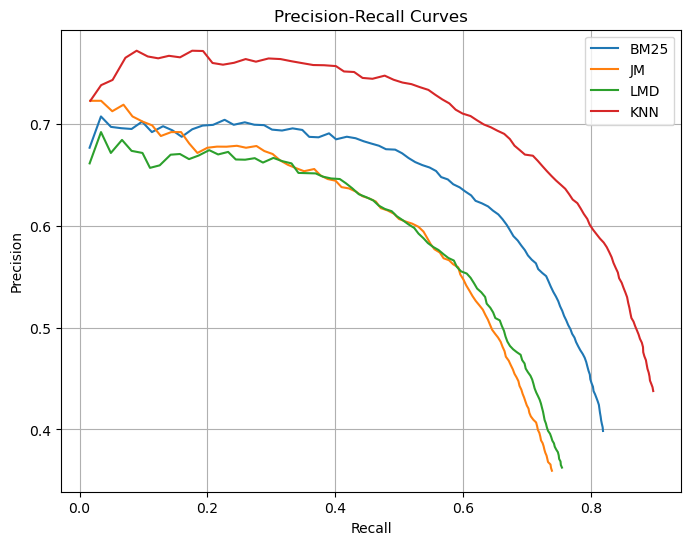

In [29]:
def precision_recall_curve(eval_queries, max_k=100):
    mean_precisions = []
    mean_recalls = []

    for k in range(1, max_k + 1):
        ps, rs = [], []

        for _, labels, ranking in eval_queries:
            ps.append(precision_at_k(ranking, labels, k))
            rs.append(recall_at_k(ranking, labels, k))

        mean_precisions.append(np.mean(ps))
        mean_recalls.append(np.mean(rs))

    return mean_recalls, mean_precisions


rec_bm25, prec_bm25 = precision_recall_curve(metrics_bm25["eval_queries_bin"], max_k=100)
rec_jm, prec_jm = precision_recall_curve(metrics_jm["eval_queries_bin"], max_k=100)
rec_lmd, prec_lmd = precision_recall_curve(metrics_lmd["eval_queries_bin"], max_k=100)
rec_knn, prec_knn = precision_recall_curve(metrics_knn["eval_queries_bin"], max_k=100)

plt.figure(figsize=(8, 6))
plt.plot(rec_bm25, prec_bm25, label="BM25")
plt.plot(rec_jm, prec_jm, label="JM")
plt.plot(rec_lmd, prec_lmd, label="LMD")
plt.plot(rec_knn, prec_knn, label="KNN")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

## Evaluation only on test topics

In [30]:
test_query_ids = {str(t["id"]) for t in test_topics}

queries_test = {qid: qtext for qid, qtext in queries.items() if qid in test_query_ids}
qrels_graded_test = {qid: rels for qid, rels in qrels_graded.items() if qid in test_query_ids}
qrels_binary_test = {qid: rels for qid, rels in qrels_binary.items() if qid in test_query_ids}

bm25_results_test = {qid: res for qid, res in bm25_results.items() if qid in test_query_ids}
jm_results_test   = {qid: res for qid, res in jm_results.items() if qid in test_query_ids}
lmd_results_test  = {qid: res for qid, res in lmd_results.items() if qid in test_query_ids}
knn_results_test  = {qid: res for qid, res in knn_results.items() if qid in test_query_ids}

In [36]:
metrics_bm25_test = evaluate_run(
    bm25_results_test, queries_test, qrels_binary_test, qrels_graded_test, all_doc_ids, run_name="BM25 TEST"
)
df_bm25_test = metrics_bm25_test["df"]

metrics_jm_test = evaluate_run(
    jm_results_test, queries_test, qrels_binary_test, qrels_graded_test, all_doc_ids, run_name="JM TEST"
)
df_jm_test = metrics_jm_test["df"]

metrics_lmd_test = evaluate_run(
    lmd_results_test, queries_test, qrels_binary_test, qrels_graded_test, all_doc_ids, run_name="LMD TEST"
)
df_lmd_test = metrics_lmd_test["df"]

metrics_knn_test = evaluate_run(
    knn_results_test, queries_test, qrels_binary_test, qrels_graded_test, all_doc_ids, run_name="KNN TEST"
)
df_knn_test = metrics_knn_test["df"]


=== BM25 TEST ===
Query |     AP |     RR |   P@10 |   R@100 |  NDCG@10 |  NDCG@100
------------------------------------------------------------------------
  116 |  0.823 |  1.000 |  0.800 |   0.958 |    0.784 |     0.916
  118 |  0.429 |  0.500 |  0.800 |   0.708 |    0.695 |     0.641
  120 |  0.509 |  1.000 |  0.900 |   0.608 |    0.841 |     0.660
  122 |  0.513 |  0.500 |  0.400 |   0.878 |    0.417 |     0.727
  124 |  0.373 |  0.333 |  0.300 |   0.964 |    0.128 |     0.618
  126 |  0.364 |  1.000 |  0.300 |   0.673 |    0.253 |     0.575
  128 |  0.794 |  1.000 |  1.000 |   0.917 |    0.951 |     0.907
  130 |  0.806 |  1.000 |  0.700 |   1.000 |    0.690 |     0.923
  132 |  0.816 |  0.333 |  0.800 |   0.963 |    0.641 |     0.888
  134 |  0.802 |  1.000 |  1.000 |   0.877 |    0.954 |     0.885
  136 |  0.551 |  1.000 |  0.600 |   0.831 |    0.604 |     0.751
  138 |  0.821 |  1.000 |  0.700 |   1.000 |    0.605 |     0.775
  140 |  0.148 |  1.000 |  0.400 |   0.365 |    0.

In [37]:
summary_df_test = pd.DataFrame([
    {"Run": "BM25", "MAP": metrics_bm25_test["MAP"], "MRR": metrics_bm25_test["MRR"], "P@10": metrics_bm25_test["P@10"], "R@100": metrics_bm25_test["R@100"], "NDCG@10": metrics_bm25_test["NDCG@10"], "NDCG@100": metrics_bm25_test["NDCG@100"]},
    {"Run": "JM",   "MAP": metrics_jm_test["MAP"],   "MRR": metrics_jm_test["MRR"],   "P@10": metrics_jm_test["P@10"],   "R@100": metrics_jm_test["R@100"],   "NDCG@10": metrics_jm_test["NDCG@10"],   "NDCG@100": metrics_jm_test["NDCG@100"]},
    {"Run": "LMD",  "MAP": metrics_lmd_test["MAP"],  "MRR": metrics_lmd_test["MRR"],  "P@10": metrics_lmd_test["P@10"],  "R@100": metrics_lmd_test["R@100"],  "NDCG@10": metrics_lmd_test["NDCG@10"],  "NDCG@100": metrics_lmd_test["NDCG@100"]},
    {"Run": "KNN",  "MAP": metrics_knn_test["MAP"],  "MRR": metrics_knn_test["MRR"],  "P@10": metrics_knn_test["P@10"],  "R@100": metrics_knn_test["R@100"],  "NDCG@10": metrics_knn_test["NDCG@10"],  "NDCG@100": metrics_knn_test["NDCG@100"]},
])

summary_df_test = summary_df_test.sort_values(by="NDCG@10", ascending=False).reset_index(drop=True)
summary_df_test

,Run,MAP,MRR,P@10,R@100,NDCG@10,NDCG@100
0,KNN,0.671876,0.825758,0.748485,0.894573,0.720673,0.824683
1,BM25,0.597935,0.863636,0.666667,0.843492,0.641706,0.765192
2,JM,0.526252,0.850289,0.660606,0.753146,0.630891,0.697629
3,LMD,0.535292,0.853535,0.651515,0.774466,0.614429,0.707646


## PR Curve Test

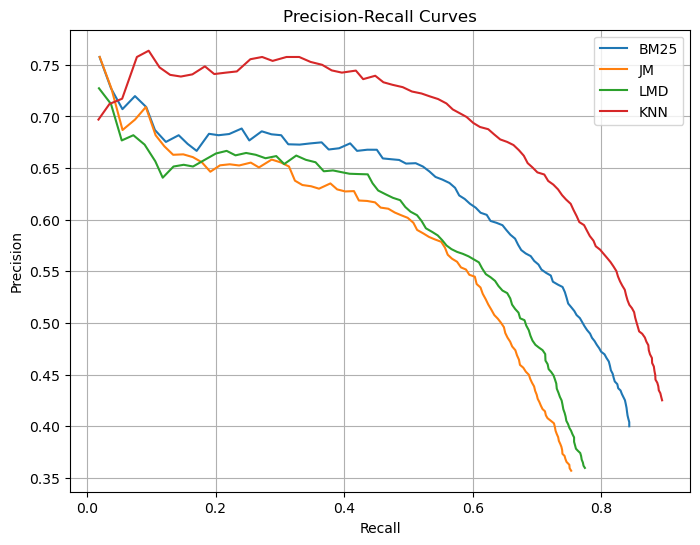

In [38]:
rec_bm25_test, prec_bm25_test = precision_recall_curve(metrics_bm25_test["eval_queries_bin"], max_k=100)
rec_jm_test, prec_jm_test = precision_recall_curve(metrics_jm_test["eval_queries_bin"], max_k=100)
rec_lmd_test, prec_lmd_test = precision_recall_curve(metrics_lmd_test["eval_queries_bin"], max_k=100)
rec_knn_test, prec_knn_test = precision_recall_curve(metrics_knn_test["eval_queries_bin"], max_k=100)

plt.figure(figsize=(8, 6))
plt.plot(rec_bm25_test, prec_bm25_test, label="BM25")
plt.plot(rec_jm_test, prec_jm_test, label="JM")
plt.plot(rec_lmd_test, prec_lmd_test, label="LMD")
plt.plot(rec_knn_test, prec_knn_test, label="KNN")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

### Query with highest and lowes AP

In [40]:
# Remove mean row
df = df_knn_test[df_knn_test["Query"] != "Mean"].copy()

# Convert AP to numeric just in case
df["AP"] = df["AP"].astype(float)

# Highest AP
best_query = df.sort_values("AP", ascending=False).iloc[0]["Query"]

# Lowest AP
worst_query = df.sort_values("AP", ascending=True).iloc[0]["Query"]

# Middle query (median AP)
middle_query = df.sort_values("AP").iloc[len(df)//2]["Query"]

print("Best:", best_query)
print("Worst:", worst_query)
print("Middle:", middle_query)

Best: 170
Worst: 156
Middle: 164


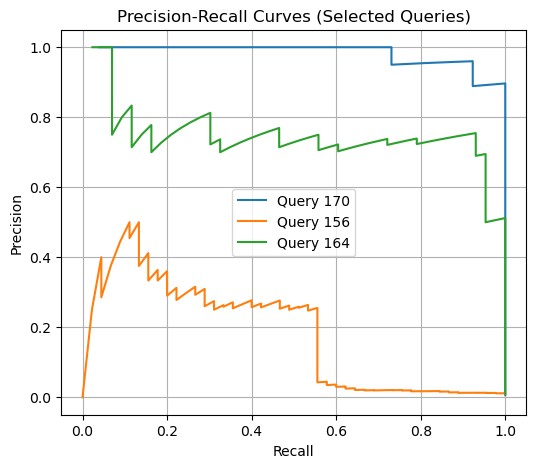

In [ ]:
def precision_recall_curve_single(ranking, labels):
    precisions = []
    recalls = []

    total_relevant = sum(labels)
    if total_relevant == 0:
        return [0], [0]

    rel_found = 0

    for k in range(1, len(ranking) + 1):
        doc_idx = ranking[k-1]

        if labels[doc_idx]:
            rel_found += 1

        precision = rel_found / k
        recall = rel_found / total_relevant

        precisions.append(precision)
        recalls.append(recall)

    return recalls, precisions

selected_qids = [best_query, worst_query, middle_query]

plt.figure(figsize=(6,5))

for qid in selected_qids:
    for q, labels, ranking in metrics_knn_test["eval_queries_bin"]:
        if q == qid:
            recalls, precisions = precision_recall_curve_single(ranking, labels)
            plt.plot(recalls, precisions, label=f"Query {qid}")
            break

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Selected Queries)")
plt.legend()
plt.grid()

plt.show()